# Lab Exercise 4: Preprocessing a Real-World Dataset
##Md Alamgir Hossain, BIS, Saskpolytech, Regina Campus

**Objective:** In this lab, you will apply various preprocessing techniques to a dataset with missing values and categorical features. You will then build a pipeline to train a classifier on the preprocessed data.

**Dataset:** We will use the Titanic dataset, which is a classic dataset for practicing data preprocessing.

### Instructions

1.  **Load the Dataset:** Load the Titanic dataset from seaborn: `sns.load_dataset('titanic')`.
2.  **Explore the Data:**
    - Identify the columns with missing values.
    - Identify the numerical and categorical columns.
3.  **Prepare the Data:**
    - Drop the `deck` column as it has too many missing values.
    - For the `age` column, fill the missing values with the median age.
    - For the `embarked` and `embark_town` columns, fill the missing values with the most frequent value.
4.  **Set up the Preprocessing Pipeline:**
    - Create a `ColumnTransformer` that applies `StandardScaler` to the numerical columns and `OneHotEncoder` to the categorical columns.
5.  **Create the Full Pipeline:**
    - Create a pipeline that includes your preprocessor and a `LogisticRegression` classifier.
6.  **Train and Evaluate:**
    - Split the data into training and testing sets.
    - Train your pipeline and evaluate its accuracy on the test set.

## Completed lab and methods

**Question:** Can passenger information available before an outcome help predict whether a Titanic passenger survived? `survived` is the target (0 = did not survive; 1 = survived). The six numbered sections correspond to the six lab instructions. The original assignment text above is preserved.

**Method:** An 80/20 stratified train/test split reserves 179 passengers for final evaluation. All missing-value estimates, scaling, encoding, and model fitting happen within pipelines trained on the training portion. Five-fold cross-validation on training data compares sensible choices; the test data is assessed once after the choice. `alive` is excluded because it directly reveals the answer. The dataset is sourced from `sns.load_dataset('titanic')`.

### 1. Load the Titanic dataset

**Why:** Inspect the size and the first records so that the column names and target are clear before modeling.

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix,
                             roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df = sns.load_dataset('titanic')
print(f'Dataset: {len(df)} passengers, {df.shape[1]} columns')
display(df.head())

Dataset: 891 passengers, 15 columns


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Result note:** Each row is one passenger. `survived` supplies the correct label during supervised learning; it will be removed from the predictor matrix.

### 2. Explore missing values and feature types

**Why:** Missing counts determine what requires imputation, while feature meanings determine whether a field needs scaling or categorical encoding.

,missing_count,missing_percent,dtype
survived,0,0.0,int64
pclass,0,0.0,int64
sex,0,0.0,object
age,177,19.9,float64
sibsp,0,0.0,int64
parch,0,0.0,int64
fare,0,0.0,float64
embarked,2,0.2,object
class,0,0.0,category
who,0,0.0,object


Numeric dtypes: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Object/category/Boolean dtypes: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Survival labels (0, 1): {0: 549, 1: 342}


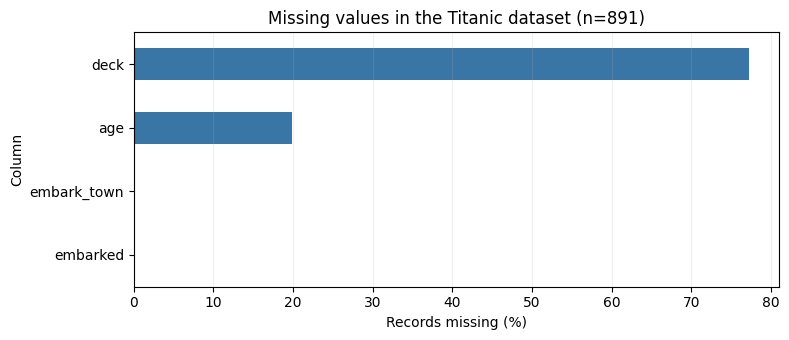

In [16]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(1),
    'dtype': df.dtypes.astype(str)
})
display(missing)
print('Numeric dtypes:', df.select_dtypes(include='number').columns.tolist())
print('Object/category/Boolean dtypes:', df.select_dtypes(exclude='number').columns.tolist())
print('Survival labels (0, 1):', df['survived'].value_counts().sort_index().to_dict())

fig, ax = plt.subplots(figsize=(8, 3.5))
missing.loc[missing.missing_count.gt(0), 'missing_percent'].sort_values().plot.barh(ax=ax, color='#3975a5')
ax.set(xlabel='Records missing (%)', ylabel='Column', title='Missing values in the Titanic dataset (n=891)')
ax.grid(axis='x', alpha=0.2)
fig.tight_layout()
plt.show()

**Result note:** `deck` is absent in 688 of 891 rows (77.2%), so the lab directs us to drop it. `age` is missing in 177 rows (19.9%). `embarked` and `embark_town` each miss 2 rows (0.2%). `pclass` is stored as an integer but represents passenger class, so treat it as categorical. `alive` is a direct translation of `survived` and would make a model's score misleading.

### 3. Prepare the data and reserve a test set

**Why:** Drop `deck` as required, select predictors, then split *before* learning replacement values. This prevents information about held-out passengers from entering the preprocessing statistics. `embarked` and `embark_town` both stay so the lab's requested mode imputation is demonstrated for each; they largely repeat the same port information, so the coefficients should not be interpreted separately.

In [17]:
prepared = df.drop(columns=['deck'])
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['sex', 'embarked', 'embark_town', 'pclass']
feature_columns = numeric_features + categorical_features
X = prepared[feature_columns].copy()
y = prepared['survived'].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print('Selected predictors:', feature_columns)
print(f'Train: {len(X_train)} rows; held-out test: {len(X_test)} rows')
print('Missing training values in the columns to impute:')
display(X_train[['age', 'embarked', 'embark_town']].isna().sum().to_frame('missing_count'))
assert 'alive' not in X.columns and 'survived' not in X.columns and 'deck' not in X.columns

Selected predictors: ['age', 'fare', 'sibsp', 'parch', 'sex', 'embarked', 'embark_town', 'pclass']
Train: 712 rows; held-out test: 179 rows
Missing training values in the columns to impute:


,missing_count
age,137
embarked,2
embark_town,2


**Result note:** The split contains 712 training rows and 179 test rows. `stratify=y` keeps the two survival classes in roughly the same proportions in both parts; `random_state=42` makes the exercise reproducible.

### 4. Set up `ColumnTransformer`

**Why choose these alternatives?** The required solution uses median imputation for `age`: the median is less sensitive to unusually high or low ages than the mean. For `embarked` and `embark_town`, the most frequent category is a simple replacement for the two missing values. Numerical fields are standardized so logistic regression can fit more reliably; one-hot encoding turns categories into indicators without inventing an order for ports or passenger class. `handle_unknown='ignore'` avoids an error if a new category appears at prediction time.

In [18]:
def make_preprocessor(age_strategy='median'):
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy=age_strategy)),
        ('scaler', StandardScaler())
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])
    return ColumnTransformer([
        ('numeric', numeric_pipeline, numeric_features),
        ('categorical', categorical_pipeline, categorical_features)
    ])

preprocessor = make_preprocessor('median')
print(preprocessor)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'fare', 'sibsp', 'parch']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'embarked', 'embark_town', 'pclass'])])


**Result note:** The imputers are defined but have not yet learned any values. They learn the age median and port modes only when the complete pipeline is fitted to training data. No manual filling is needed before the split.

### 5. Build logistic regression and compare training-only alternatives

**Why add a comparison?** The assignment requires logistic regression, so that remains the final classifier. A majority-class `DummyClassifier` tells us how often a model could be right without using passenger characteristics. Mean imputation is an alternative to the requested median; we compare it using the *same* training folds. Five-fold stratified cross-validation repeats fitting on distinct training folds, including preprocessing, so each validation fold is unseen by its fitted pipeline. The held-out test set is not used for this choice.

In [19]:
median_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
mean_model = Pipeline([
    ('preprocessor', make_preprocessor('mean')),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
majority_baseline = DummyClassifier(strategy='most_frequent')

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for label, candidate in [('Majority-class baseline', majority_baseline),
                         ('Logistic regression + median', median_model),
                         ('Logistic regression + mean', mean_model)]:
    scores = cross_validate(candidate, X_train, y_train, cv=folds,
                            scoring={'accuracy':'accuracy', 'balanced':'balanced_accuracy'})
    results.append({'Method':label,
                    'CV accuracy mean':scores['test_accuracy'].mean(),
                    'CV accuracy SD':scores['test_accuracy'].std(),
                    'CV balanced accuracy mean':scores['test_balanced'].mean()})
cv_results = pd.DataFrame(results).set_index('Method')
display(cv_results.round(3))

,CV accuracy mean,CV accuracy SD,CV balanced accuracy mean
Method,,,
Majority-class baseline,0.617,0.003,0.500
Logistic regression + median,0.802,0.014,0.783
Logistic regression + mean,0.799,0.019,0.780


**Result note:** Across five training folds, the majority baseline averaged **0.617 accuracy**, while logistic regression averaged **0.802** with median and **0.799** with mean imputation. The standard deviations in the table show variation across folds. The majority classifier has balanced accuracy 0.5 because it never identifies the minority class. We retain median imputation because the lab calls for it and it is less sensitive to extreme ages; a small difference between strategies does not prove one is generally superior.

### 6. Train the required pipeline and evaluate once on the test set

**Why these measures?** Accuracy answers the explicit lab requirement. The confusion matrix shows which passengers were classified incorrectly. Survivor recall checks how many actual survivors were recognized, balanced accuracy gives both classes equal weight, and ROC AUC summarizes ranking across probability thresholds. These extra measures provide context without changing the requested classifier.

Test accuracy: 0.8045 (80.45%)
Test balanced accuracy: 0.7788
Test ROC AUC: 0.8426
Classification report:
                 precision    recall  f1-score   support

Did not survive       0.81      0.89      0.85       110
       Survived       0.79      0.67      0.72        69

       accuracy                           0.80       179
      macro avg       0.80      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



,Predicted 0,Predicted 1
Actual 0: did not survive,98,12
Actual 1: survived,23,46


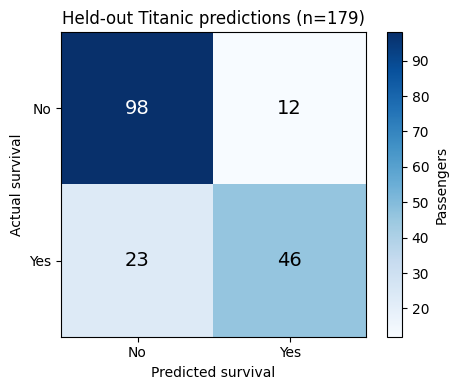

In [20]:
median_model.fit(X_train, y_train)
y_pred = median_model.predict(X_test)
y_score = median_model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
balanced = balanced_accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_score)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
print(f'Test accuracy: {accuracy:.4f} ({accuracy:.2%})')
print(f'Test balanced accuracy: {balanced:.4f}')
print(f'Test ROC AUC: {auc:.4f}')
print('Classification report:')
print(classification_report(y_test, y_pred, labels=[0, 1],
                            target_names=['Did not survive', 'Survived']))
display(pd.DataFrame(cm, index=['Actual 0: did not survive', 'Actual 1: survived'],
                     columns=['Predicted 0', 'Predicted 1']))

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(cm, cmap='Blues')
for row in range(2):
    for column in range(2):
        ax.text(column, row, cm[row, column], ha='center', va='center',
                color='white' if cm[row, column] > cm.max() / 2 else 'black', fontsize=14)
ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=['No', 'Yes'],
       yticklabels=['No', 'Yes'], xlabel='Predicted survival',
       ylabel='Actual survival', title='Held-out Titanic predictions (n=179)')
fig.colorbar(image, ax=ax, label='Passengers')
fig.tight_layout()
plt.show()

**Result note:** The model correctly classified **144 of 179** held-out passengers (**80.45% accuracy**). It found **46 of 69** actual survivors (66.7% survivor recall). There were 12 false survivor predictions and 23 missed survivors. Balanced accuracy was 0.779; ROC AUC was 0.843. These describe one held-out split, not guaranteed performance elsewhere. The results are predictive associations, not evidence of what caused survival.

### Check the actual learned replacements

**Why:** This confirms that median/mode imputation really occurred in the fitted pipeline and shows the numerical values chosen from the training portion.

In [21]:
fitted_parts = median_model.named_steps['preprocessor'].named_transformers_
numeric_stats = fitted_parts['numeric'].named_steps['imputer'].statistics_
category_stats = fitted_parts['categorical'].named_steps['imputer'].statistics_
print('Training-set age median:', numeric_stats[numeric_features.index('age')])
print('Training-set most frequent embarkation codes and towns:')
for name in ['embarked', 'embark_town']:
    print(f'  {name}: {category_stats[categorical_features.index(name)]}')
print('Missing values remaining after pipeline transformation:',
      np.isnan(median_model.named_steps['preprocessor'].transform(X_test)).sum())

Training-set age median: 28.5
Training-set most frequent embarkation codes and towns:
  embarked: S
  embark_town: Southampton
Missing values remaining after pipeline transformation: 0


**Result note:** The imputer values printed above come from the training records. The transformed held-out predictors have no missing numerical entries. `embarked` and `embark_town` refer to the same embarkation location in different forms, so keeping both meets the exercise's handling requirement but adds little new information.

### Conclusion and limits

The requested `ColumnTransformer` and `LogisticRegression` pipeline is complete: `deck` was removed, missing ages were handled with a training-set median, missing ports with training-set modes, numerical features were scaled, categories were encoded, and held-out accuracy was measured. Training-only cross-validation and a majority baseline help put the score in context. The Titanic sample is small and historical; it supports a classroom demonstration, not claims about other travel settings. An optional next experiment is removing the redundant `embark_town` feature and comparing cross-validation scores *without* reusing the test set to choose a model.